Размер датасета: (839364, 5)

Пропуски в данных:
Unnamed: 0          0
Sentence_id    800997
Word                9
POS                 0
Tag                 0
dtype: int64


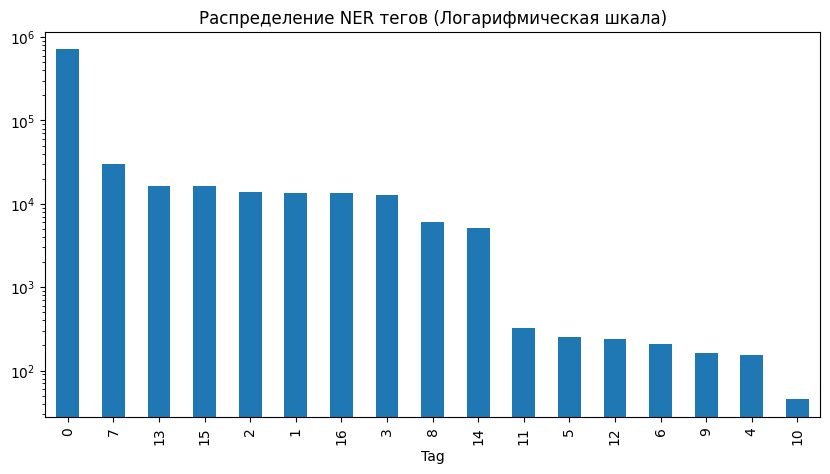


Количество каждого тега:
Tag
0     710524
7      30338
13     16239
15     16140
2      13903
1      13573
16     13462
3      12662
8       5987
14      5152
11       321
5        252
12       241
6        206
9        164
4        155
10        45
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib
import os

train_df = pd.read_csv('./data/train.csv')

print("Размер датасета:", train_df.shape)
print("\nПропуски в данных:")
print(train_df.isnull().sum())

plt.figure(figsize=(10, 5))
train_df['Tag'].value_counts().plot(kind='bar', logy=True) # logy=True потому что тега O будет слишком много
plt.title('Распределение NER тегов (Логарифмическая шкала)')
plt.show()

print("\nКоличество каждого тега:")
print(train_df['Tag'].value_counts())

In [2]:
train_df['Sentence_id'] = train_df['Sentence_id'].ffill()

train_df['Word'] = train_df['Word'].fillna("UNKNOWN")

sentences_df = train_df.groupby('Sentence_id').agg({
    'Word': list,
    'Tag': list
}).reset_index()

print(f"Итого собрано предложений: {len(sentences_df)}")
print("\nПример первого собранного предложения:")
print("Слова: ", sentences_df['Word'].iloc[0][:10]) 
print("Теги:  ", sentences_df['Tag'].iloc[0][:10])  

Итого собрано предложений: 38367

Пример первого собранного предложения:
Слова:  ['Thousands', 'of', 'demonstrators', 'have', 'marched', 'through', 'London', 'to', 'protest', 'the']
Теги:   [0, 0, 0, 0, 0, 0, 7, 0, 0, 0]


In [3]:
# Функция для создания признаков одного слова с учетом соседей
def word2features(sent, i):
    word = str(sent[i]) # Защита от нестроковых типов
    
    # Базовые признаки самого слова
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],  
        'word[-2:]': word[-2:],
        'word[:2]': word[:2],   
        'word[:3]': word[:3],
        'word.length': len(word),          
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
    }
    
    # Признаки предыдущего слова
    if i > 0:
        word1 = str(sent[i-1])
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True
        
    # Признаки след. слова
    if i < len(sent)-1:
        word1 = str(sent[i+1])
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True
        
    return features

In [4]:
# Функции-обертки для обработки предложений
def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(tags):
    return [str(tag) for tag in tags] # CRF требует строковые метки

In [5]:
print("Извлекаем признаки...")
X = [sent2features(s) for s in sentences_df['Word'].tolist()]
y = [sent2labels(s) for s in sentences_df['Tag'].tolist()]

#Разбиваем данные на обучающую и валидационную часть
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Готово. Предложений для обучения: {len(X_train)}")
print(f"Предложений для проверки: {len(X_test)}")

Извлекаем признаки...
Готово. Предложений для обучения: 30693
Предложений для проверки: 7674


In [10]:
import sklearn_crfsuite
from sklearn_crfsuite import metrics

# Инициализируем CRF-модель 
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.25,  # Коэффициент L1-регуляризации
    c2=0.05,  # Коэффициент L2-регуляризации
    max_iterations=100,
    all_possible_transitions=True
)

# Обучаем
print("Обучаем CRF-модель... ")
crf.fit(X_train, y_train)
print("Обучение завершено!")

# Делаем предсказания на тестовой выборке
y_pred = crf.predict(X_test)

# Считаем метрики
labels = list(crf.classes_)
if '0' in labels:
    labels.remove('0')

# Считаем взвешенную F1-меру
f1 = metrics.flat_f1_score(y_test, y_pred, average='weighted', labels=labels)
print(f"Итоговая F1-мера (без учета тега '0'): {f1:.4f}")

print("\nПодробный отчет по классам:")
print(metrics.flat_classification_report(y_test, y_pred, labels=labels, digits=3))

Обучаем CRF-модель... 
Обучение завершено!
Итоговая F1-мера (без учета тега '0'): 0.8438

Подробный отчет по классам:
              precision    recall  f1-score   support

           3      0.949     0.936     0.943      2548
          15      0.800     0.716     0.756      3252
          16      0.809     0.785     0.797      2750
           7      0.853     0.904     0.878      6112
          13      0.921     0.875     0.897      3250
           1      0.848     0.809     0.828      2730
           2      0.849     0.885     0.867      2812
           8      0.805     0.808     0.807      1305
          14      0.828     0.768     0.797      1025
           9      0.737     0.438     0.549        32
           5      0.467     0.280     0.350        50
           6      0.150     0.071     0.097        42
          11      0.300     0.100     0.150        60
          12      0.118     0.061     0.080        33
           4      0.815     0.550     0.657        40
          10     

In [11]:
os.makedirs('./models', exist_ok=True)

#Сохраняем саму обученную модель
model_path = './models/crf_model.joblib'
joblib.dump(crf, model_path)

print(f"Модель успешно сохранена по пути: {model_path}")
print("Размер файла:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

Модель успешно сохранена по пути: ./models/crf_model.joblib
Размер файла: 2.51 MB


In [12]:
import pandas as pd

test_df = pd.read_csv('./data/test.csv')

test_df['Sentence_id'] = test_df['Sentence_id'].ffill()
test_df['Word'] = test_df['Word'].fillna("UNKNOWN")

test_sentences = test_df.groupby('Sentence_id')['Word'].apply(list).tolist()

print("Извлекаем признаки для test.csv...")
X_submission = [sent2features(s) for s in test_sentences]

print("Делаем предсказания...")
y_pred_submission = crf.predict(X_submission)

flat_predictions = [tag for sentence_tags in y_pred_submission for tag in sentence_tags]

submission_df = pd.DataFrame({
    'ID': range(len(flat_predictions)), 
    'TARGET': flat_predictions
})

submission_df.to_csv('final_submission.csv', index=False)
print("Файл final_submission.csv готов.")

Извлекаем признаки для test.csv...
Делаем предсказания...
Файл final_submission.csv готов.
